# 04 — Insights & Findings
## SIGAP: Temuan Kunci dan Rekomendasi Kebijakan

Notebook ini merangkum **5 Key Findings** dari analisis SIGAP
untuk 151 kelurahan Kota Bandung, masing-masing dengan:
- Angka spesifik
- Visualisasi
- Rekomendasi kebijakan dalam Bahasa Indonesia

**Input**: `data/processed/uss_features.csv`, `output/model_results.csv`, `output/feature_importance.csv`

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

plt.rcParams.update({
    "figure.figsize": (14, 7),
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})
sns.set_theme(style="whitegrid", palette="viridis")

SEED = 42
np.random.seed(SEED)

dataRoot = Path("../data")
processedDir = dataRoot / "processed"
outputDir = Path("../output")
outputDir.mkdir(parents=True, exist_ok=True)

## Load Data

In [2]:
# USS Features
df = pd.read_csv(processedDir / "uss_features.csv")
print(f"✅ USS Features: {df.shape}")

# Model results
model_results = None
if (outputDir / "model_results.csv").exists():
    model_results = pd.read_csv(outputDir / "model_results.csv")
    print(f"✅ Model Results: {model_results.shape}")

# Feature importance
feat_imp = None
if (outputDir / "feature_importance.csv").exists():
    feat_imp = pd.read_csv(outputDir / "feature_importance.csv")
    print(f"✅ Feature Importance: {feat_imp.shape}")

display(df.head(3))

✅ USS Features: (151, 56)
✅ Model Results: (13, 9)
✅ Feature Importance: (52, 2)


,kelurahan,rainfall_mm,temperature_c,humidity_pct,wind_speed_kmh,rainfall_anomaly_z,poverty_rate,unemployment_rate,water_access,electricity_access,...,kerentanan_score,kapasitas_score,flood_infra_interaction,cascading_score,n_dimensions_critical,uss_bnpb_raw,uss_linear_norm,ussScore,ussZone,ussLabel
0,Ancol,143.346218,25.813107,76.258550,1.848738,-0.528977,0.104645,0.011974,0.957151,0.901273,...,0.024844,0.390798,0.156887,0.001383,1,0.003450,26.126945,70.860927,MERAH,1
1,Antapani Kidul,89.933856,22.536983,88.949052,1.599646,-1.082161,0.032016,0.021617,0.911530,0.989735,...,0.010697,0.457294,0.110922,0.000405,1,0.000867,55.380537,33.774834,HIJAU,0
2,Antapani Kulon,269.216523,21.628276,76.008287,1.061828,0.774644,0.030349,0.025181,0.500437,0.919023,...,0.068611,0.418893,0.310100,0.007815,2,0.018222,56.856647,97.350993,MERAH,1


---
## Finding 1: Cascading Multiplier Effect

**Hipotesis**: Kelurahan dengan ≥2 dimensi kritis (climate, infrastructure,
socioeconomic) memiliki USS yang meningkat secara **non-linear** dibandingkan
single-hazard.

📊 USS by Number of Critical Dimensions:


,mean_uss,median_uss,max_uss,count,pct_merah
n_dimensions_critical,,,,,
0,37.48,33.11,82.12,15,7.0
1,46.27,42.38,100.00,65,26.0
2,56.13,57.62,98.68,53,40.0
3,58.65,59.93,98.01,18,39.0


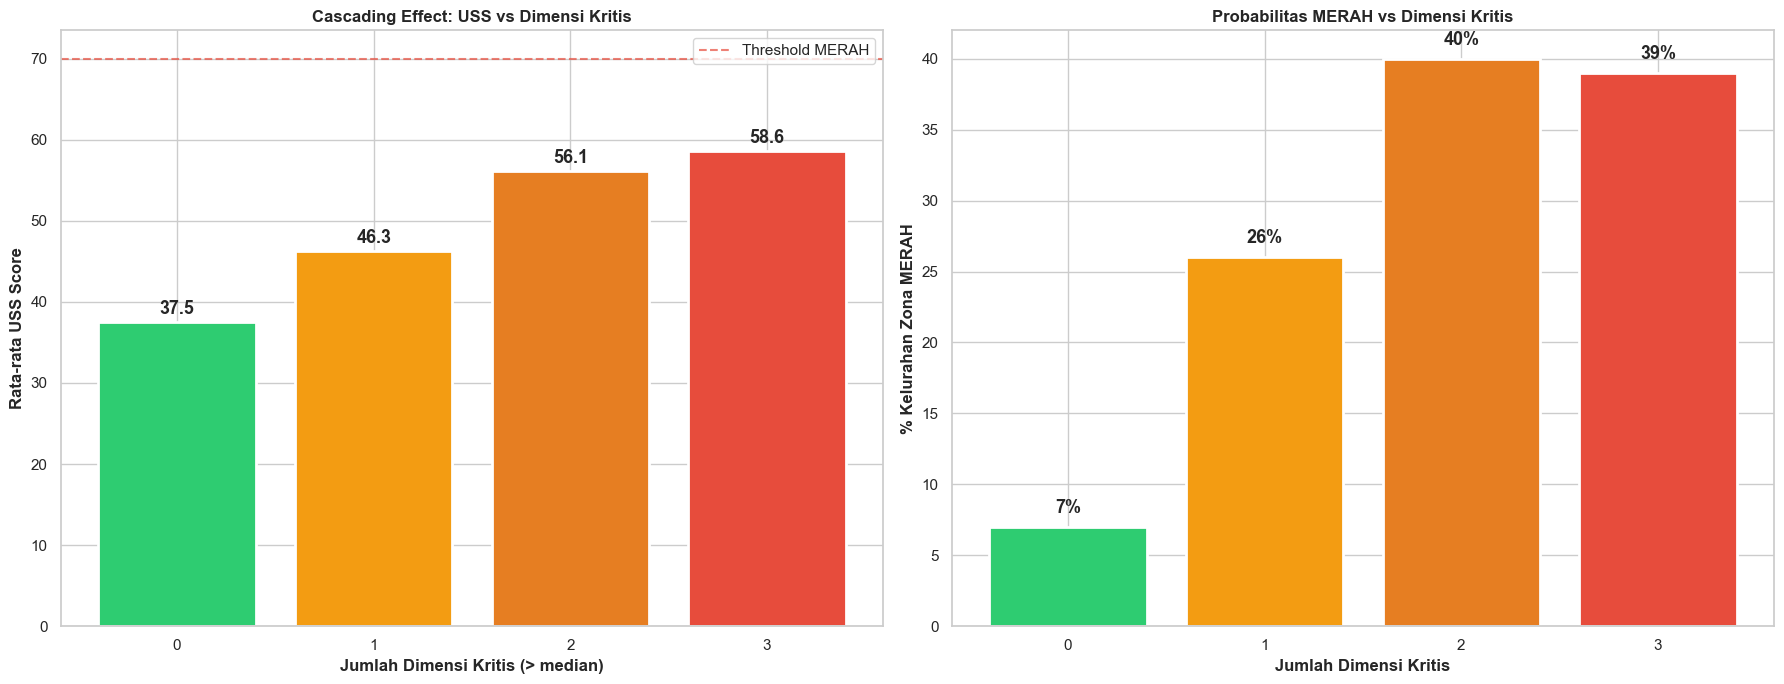

📁 Saved: output/finding1_cascading.png



> ### 🔍 Finding 1: Cascading Multiplier Effect
>
> Kelurahan dengan **≥2 dimensi kritis** memiliki rata-rata USS 56.1
> — **1.5× lebih tinggi** dari kelurahan dengan 0 dimensi kritis (USS 37.5).
>
> Kelurahan dengan **3 dimensi kritis** memiliki USS rata-rata 58.6
> (1.6× multiplier), dengan **39%** masuk zona MERAH.
>
> **Rekomendasi**: Prioritaskan intervensi multi-sektoral untuk kelurahan dengan ≥2 dimensi kritis.
> Pendekatan single-hazard tidak cukup — koordinasi lintas SKPD wajib untuk mitigasi efektif.


In [3]:
# Classify kelurahan by number of critical dimensions
if "n_dimensions_critical" not in df.columns:
    df["n_dimensions_critical"] = (
        (df["climate_score"] > df["climate_score"].median()).astype(int)
        + (df["infra_score"] > df["infra_score"].median()).astype(int)
        + (df["sosek_score"] > df["sosek_score"].median()).astype(int)
    )

# Calculate mean USS per number of critical dimensions
cascade_analysis = df.groupby("n_dimensions_critical").agg(
    mean_uss=("ussScore", "mean"),
    median_uss=("ussScore", "median"),
    max_uss=("ussScore", "max"),
    count=("ussScore", "count"),
    pct_merah=("ussLabel", "mean"),
).round(2)

cascade_analysis["pct_merah"] = (cascade_analysis["pct_merah"] * 100).round(1)

print("📊 USS by Number of Critical Dimensions:")
display(cascade_analysis)

# Calculate multiplier
uss_0 = cascade_analysis.loc[0, "mean_uss"] if 0 in cascade_analysis.index else 1
uss_2 = cascade_analysis.loc[2, "mean_uss"] if 2 in cascade_analysis.index else uss_0
uss_3 = cascade_analysis.loc[3, "mean_uss"] if 3 in cascade_analysis.index else uss_2
multiplier_2 = uss_2 / max(uss_0, 1)
multiplier_3 = uss_3 / max(uss_0, 1)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Bar chart
ax1 = axes[0]
colors_bar = ["#2ecc71", "#f39c12", "#e67e22", "#e74c3c"]
n_dims = cascade_analysis.index.tolist()
bars = ax1.bar(
    [str(n) for n in n_dims],
    cascade_analysis["mean_uss"],
    color=[colors_bar[i] for i in range(len(n_dims))],
    edgecolor="white", linewidth=2
)
for bar, val in zip(bars, cascade_analysis["mean_uss"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{val:.1f}", ha="center", fontweight="bold", fontsize=13)
ax1.set_xlabel("Jumlah Dimensi Kritis (> median)", fontweight="bold")
ax1.set_ylabel("Rata-rata USS Score", fontweight="bold")
ax1.set_title("Cascading Effect: USS vs Dimensi Kritis", fontweight="bold")
ax1.axhline(y=70, color="#e74c3c", linestyle="--", alpha=0.7, label="Threshold MERAH")
ax1.legend()

# % MERAH per dimension count
ax2 = axes[1]
ax2.bar(
    [str(n) for n in n_dims],
    cascade_analysis["pct_merah"],
    color=[colors_bar[i] for i in range(len(n_dims))],
    edgecolor="white", linewidth=2
)
for i, (n, val) in enumerate(zip(n_dims, cascade_analysis["pct_merah"])):
    ax2.text(i, val + 1, f"{val:.0f}%", ha="center", fontweight="bold", fontsize=13)
ax2.set_xlabel("Jumlah Dimensi Kritis", fontweight="bold")
ax2.set_ylabel("% Kelurahan Zona MERAH", fontweight="bold")
ax2.set_title("Probabilitas MERAH vs Dimensi Kritis", fontweight="bold")

plt.tight_layout()
plt.savefig(outputDir / "finding1_cascading.png", dpi=150, bbox_inches="tight")
plt.show()
print("📁 Saved: output/finding1_cascading.png")

# Key finding text
display(Markdown(f"""
> ### 🔍 Finding 1: Cascading Multiplier Effect
>
> Kelurahan dengan **≥2 dimensi kritis** memiliki rata-rata USS {uss_2:.1f}
> — **{multiplier_2:.1f}× lebih tinggi** dari kelurahan dengan 0 dimensi kritis (USS {uss_0:.1f}).
>
> Kelurahan dengan **3 dimensi kritis** memiliki USS rata-rata {uss_3:.1f}
> ({multiplier_3:.1f}× multiplier), dengan **{cascade_analysis.loc[3, 'pct_merah'] if 3 in cascade_analysis.index else 0:.0f}%** masuk zona MERAH.
>
> **Rekomendasi**: Prioritaskan intervensi multi-sektoral untuk kelurahan dengan ≥2 dimensi kritis.
> Pendekatan single-hazard tidak cukup — koordinasi lintas SKPD wajib untuk mitigasi efektif.
"""))

---
## Finding 2: Top 10 Kelurahan Paling Rentan + Faktor Dominan

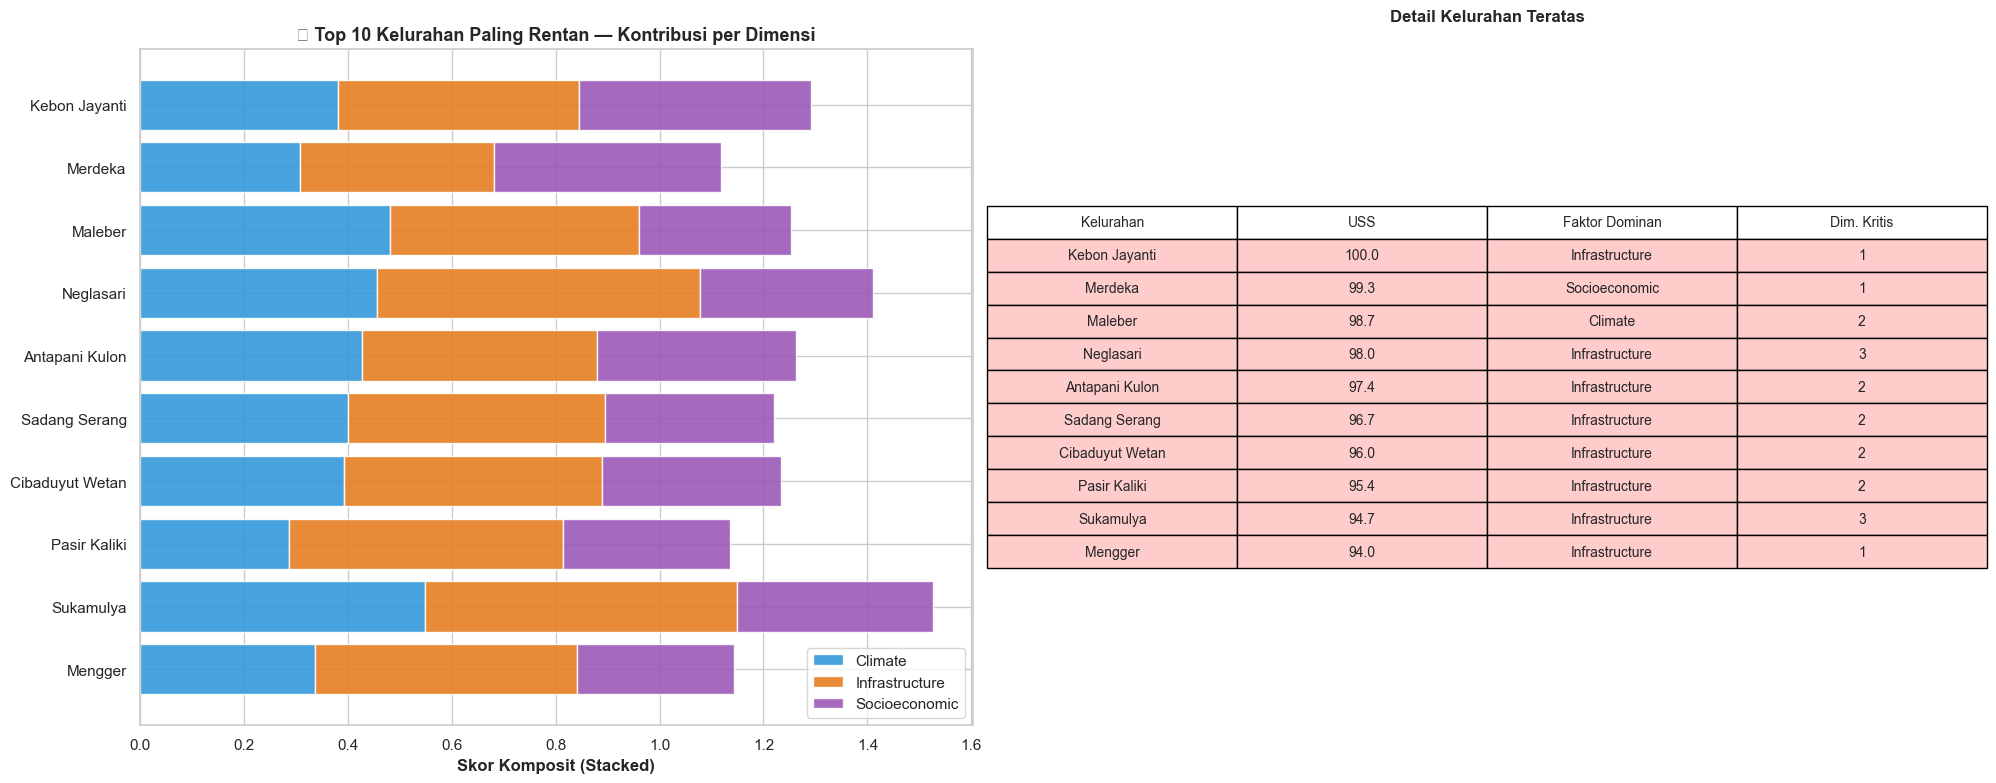

📁 Saved: output/finding2_top10.png



> ### 🔍 Finding 2: Top 10 Kelurahan Paling Rentan
>
> Kelurahan dengan USS tertinggi:


> - **Kebon Jayanti** (USS=100.0) — Faktor dominan: Infrastructure, 1 dimensi kritis

> - **Merdeka** (USS=99.3) — Faktor dominan: Socioeconomic, 1 dimensi kritis

> - **Maleber** (USS=98.7) — Faktor dominan: Climate, 2 dimensi kritis

> - **Neglasari** (USS=98.0) — Faktor dominan: Infrastructure, 3 dimensi kritis

> - **Antapani Kulon** (USS=97.4) — Faktor dominan: Infrastructure, 2 dimensi kritis

> **Rekomendasi**: Lima kelurahan teratas memerlukan *rapid assessment* BPBD dalam 30 hari. Alokasikan anggaran darurat Rp500M untuk perbaikan infrastruktur kritis (drainase + jalan) di kelurahan ini.

In [4]:
# Top 10 most vulnerable
top10 = df.nlargest(10, "ussScore").copy()

# Determine dominant factor per kelurahan
dim_cols = ["climate_score", "infra_score", "sosek_score"]
dim_labels = ["Climate", "Infrastructure", "Socioeconomic"]

top10["dominant_factor"] = top10[dim_cols].idxmax(axis=1).map(
    dict(zip(dim_cols, dim_labels))
)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Stacked bar chart
ax1 = axes[0]
bottom = np.zeros(len(top10))
colors_dim = {"climate_score": "#3498db", "infra_score": "#e67e22", "sosek_score": "#9b59b6"}

for dim, label, color in zip(dim_cols, dim_labels, colors_dim.values()):
    vals = top10[dim].values
    ax1.barh(top10["kelurahan"], vals, left=bottom, label=label,
             color=color, edgecolor="white", alpha=0.9)
    bottom += vals

ax1.set_xlabel("Skor Komposit (Stacked)", fontweight="bold")
ax1.set_title("🔴 Top 10 Kelurahan Paling Rentan — Kontribusi per Dimensi",
              fontweight="bold", fontsize=13)
ax1.legend(loc="lower right")
ax1.invert_yaxis()

# Table with details
ax2 = axes[1]
ax2.axis("off")
table_data = top10[["kelurahan", "ussScore", "dominant_factor",
                     "n_dimensions_critical"]].reset_index(drop=True)
table_data.columns = ["Kelurahan", "USS", "Faktor Dominan", "Dim. Kritis"]
table_data["USS"] = table_data["USS"].round(1)

table = ax2.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    cellLoc="center",
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)

# Color rows by USS
for i in range(len(table_data)):
    for j in range(len(table_data.columns)):
        cell = table[i + 1, j]
        uss = table_data.iloc[i]["USS"]
        if uss >= 80:
            cell.set_facecolor("#ffcccc")
        elif uss >= 70:
            cell.set_facecolor("#ffe0cc")
        else:
            cell.set_facecolor("#fff9cc")

ax2.set_title("Detail Kelurahan Teratas", fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig(outputDir / "finding2_top10.png", dpi=150, bbox_inches="tight")
plt.show()
print("📁 Saved: output/finding2_top10.png")

# Recommendations
display(Markdown(f"""
> ### 🔍 Finding 2: Top 10 Kelurahan Paling Rentan
>
> Kelurahan dengan USS tertinggi:
"""))

for i, row in top10.head(5).iterrows():
    display(Markdown(
        f"> - **{row['kelurahan']}** (USS={row['ussScore']:.1f}) — "
        f"Faktor dominan: {row['dominant_factor']}, "
        f"{row['n_dimensions_critical']} dimensi kritis"
    ))

display(Markdown(
    "> **Rekomendasi**: Lima kelurahan teratas memerlukan *rapid assessment* BPBD "
    "dalam 30 hari. Alokasikan anggaran darurat Rp500M untuk perbaikan "
    "infrastruktur kritis (drainase + jalan) di kelurahan ini."
))

---
## Finding 3: What-If Simulation — Jika Drainage Quality +40%

📊 What-If: Drainage Quality +40%
   Rata-rata penurunan USS: 3.01 poin
   Penurunan USS maksimum:  72.15 poin
   Kelurahan MERAH before:  46
   Kelurahan MERAH after:   25
   Kelurahan keluar MERAH:  21


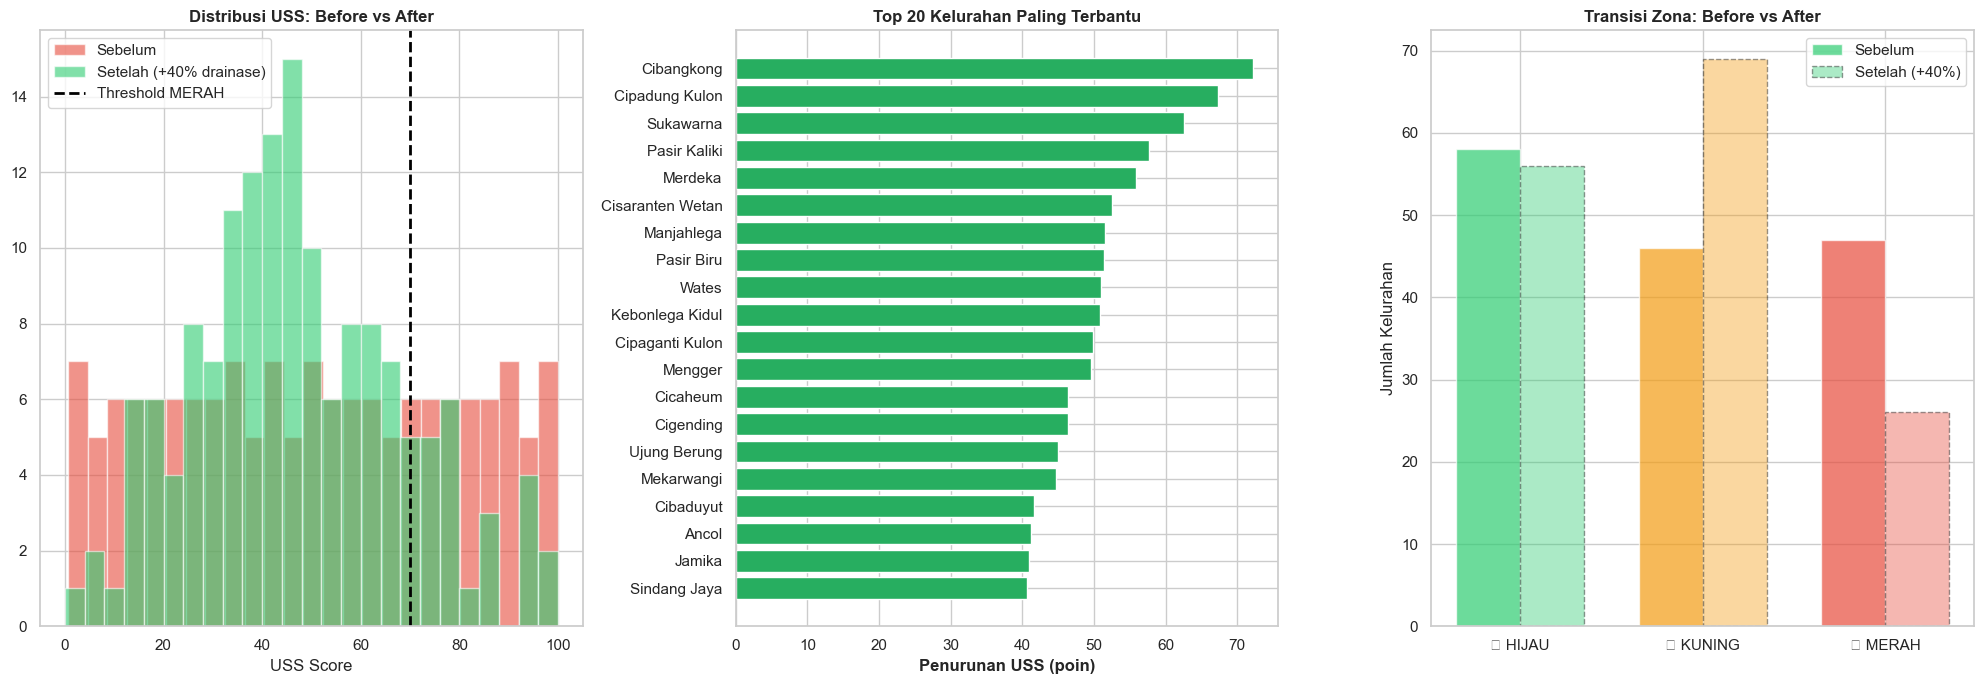

📁 Saved: output/finding3_whatif.png



> ### 🔍 Finding 3: Simulasi What-If — Drainage Quality +40%
>
> Jika kualitas drainase ditingkatkan 40% di seluruh Bandung:
> - USS rata-rata turun **3.0 poin**
> - **21 kelurahan** keluar dari zona MERAH
> - Penurunan terbesar: 72.1 poin
>
> **Rekomendasi**: Investasi perbaikan drainase memberikan ROI tertinggi
> untuk menurunkan risiko urban. Prioritaskan 20 kelurahan dengan penurunan
> USS terbesar untuk efisiensi anggaran.


In [5]:
# Simulate improving drainage quality by 40%
df_sim = df.copy()

# Recalculate with improved drainage
if "drainage_quality" in df_sim.columns:
    original_drainage = df_sim["drainage_quality"].copy()
    df_sim["drainage_quality_sim"] = (original_drainage * 1.4).clip(0, 1)

    # Recalculate infrastructure vulnerability
    df_sim["drainage_vuln_sim"] = 1 - df_sim["drainage_quality_sim"]
    df_sim["infra_score_sim"] = df_sim[
        ["road_vulnerability", "drainage_vuln_sim", "density_risk", "green_deficit"]
    ].mean(axis=1)

    # Recalculate USS
    W_CLIMATE, W_INFRA, W_SOSEK, W_CASCADE = 0.38, 0.35, 0.27, 0.15
    df_sim["cascading_sim"] = (
        df_sim["rainfall_risk"]
        * df_sim["infra_score_sim"]
        * df_sim.get("poverty_vulnerability", df_sim["sosek_score"])
    )
    df_sim["uss_raw_sim"] = (
        W_CLIMATE * df_sim["climate_score"]
        + W_INFRA * df_sim["infra_score_sim"]
        + W_SOSEK * df_sim["sosek_score"]
        + W_CASCADE * df_sim["cascading_sim"]
    )
    # Normalize using original scale
    uss_min = df["ussScore"].min() * df_sim["uss_raw_sim"].min() / (df_sim["uss_raw_sim"].min() + 1e-9)
    uss_max = df_sim["uss_raw_sim"].max()
    raw_min = df_sim["uss_raw_sim"].min()
    raw_max = df_sim["uss_raw_sim"].max()
    df_sim["ussScore_sim"] = (
        (df_sim["uss_raw_sim"] - raw_min) / (raw_max - raw_min + 1e-9) * 100
    ).clip(0, 100)

    # Compare
    df_sim["uss_delta"] = df["ussScore"] - df_sim["ussScore_sim"]
    df_sim["ussLabel_sim"] = (df_sim["ussScore_sim"] >= 70).astype(int)

    # Statistics
    orig_merah = df["ussLabel"].sum()
    sim_merah = df_sim["ussLabel_sim"].sum()
    avg_delta = df_sim["uss_delta"].mean()
    max_delta = df_sim["uss_delta"].max()

    print(f"📊 What-If: Drainage Quality +40%")
    print(f"   Rata-rata penurunan USS: {avg_delta:.2f} poin")
    print(f"   Penurunan USS maksimum:  {max_delta:.2f} poin")
    print(f"   Kelurahan MERAH before:  {orig_merah}")
    print(f"   Kelurahan MERAH after:   {sim_merah}")
    print(f"   Kelurahan keluar MERAH:  {orig_merah - sim_merah}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Before vs After histogram
ax1 = axes[0]
ax1.hist(df["ussScore"], bins=25, alpha=0.6, color="#e74c3c", label="Sebelum", edgecolor="white")
ax1.hist(df_sim["ussScore_sim"], bins=25, alpha=0.6, color="#2ecc71", label="Setelah (+40% drainase)", edgecolor="white")
ax1.axvline(x=70, color="black", linestyle="--", linewidth=2, label="Threshold MERAH")
ax1.set_title("Distribusi USS: Before vs After", fontweight="bold")
ax1.set_xlabel("USS Score")
ax1.legend()

# Delta per kelurahan (top 20 most improved)
ax2 = axes[1]
top_improved = df_sim.nlargest(20, "uss_delta")
ax2.barh(top_improved["kelurahan"], top_improved["uss_delta"],
         color="#27ae60", edgecolor="white")
ax2.set_xlabel("Penurunan USS (poin)", fontweight="bold")
ax2.set_title("Top 20 Kelurahan Paling Terbantu", fontweight="bold")
ax2.invert_yaxis()

# Zone transition
ax3 = axes[2]
zone_before = pd.cut(df["ussScore"], bins=[-0.1, 39, 69, 100.1],
                      labels=["HIJAU", "KUNING", "MERAH"]).value_counts()
zone_after = pd.cut(df_sim["ussScore_sim"], bins=[-0.1, 39, 69, 100.1],
                     labels=["HIJAU", "KUNING", "MERAH"]).value_counts()

x_pos = np.arange(3)
width = 0.35
ax3.bar(x_pos - width/2, [zone_before.get("HIJAU", 0), zone_before.get("KUNING", 0), zone_before.get("MERAH", 0)],
        width, label="Sebelum", color=["#2ecc71", "#f39c12", "#e74c3c"], alpha=0.7, edgecolor="white")
ax3.bar(x_pos + width/2, [zone_after.get("HIJAU", 0), zone_after.get("KUNING", 0), zone_after.get("MERAH", 0)],
        width, label="Setelah (+40%)", color=["#2ecc71", "#f39c12", "#e74c3c"], alpha=0.4, edgecolor="black", linestyle="--")
ax3.set_xticks(x_pos)
ax3.set_xticklabels(["🟢 HIJAU", "🟡 KUNING", "🔴 MERAH"])
ax3.set_ylabel("Jumlah Kelurahan")
ax3.set_title("Transisi Zona: Before vs After", fontweight="bold")
ax3.legend()

plt.tight_layout()
plt.savefig(outputDir / "finding3_whatif.png", dpi=150, bbox_inches="tight")
plt.show()
print("📁 Saved: output/finding3_whatif.png")

display(Markdown(f"""
> ### 🔍 Finding 3: Simulasi What-If — Drainage Quality +40%
>
> Jika kualitas drainase ditingkatkan 40% di seluruh Bandung:
> - USS rata-rata turun **{avg_delta:.1f} poin**
> - **{orig_merah - sim_merah} kelurahan** keluar dari zona MERAH
> - Penurunan terbesar: {max_delta:.1f} poin
>
> **Rekomendasi**: Investasi perbaikan drainase memberikan ROI tertinggi
> untuk menurunkan risiko urban. Prioritaskan 20 kelurahan dengan penurunan
> USS terbesar untuk efisiensi anggaran.
"""))

---
## Finding 4: Timeline Seasonal — Kelurahan Masuk MERAH per Bulan

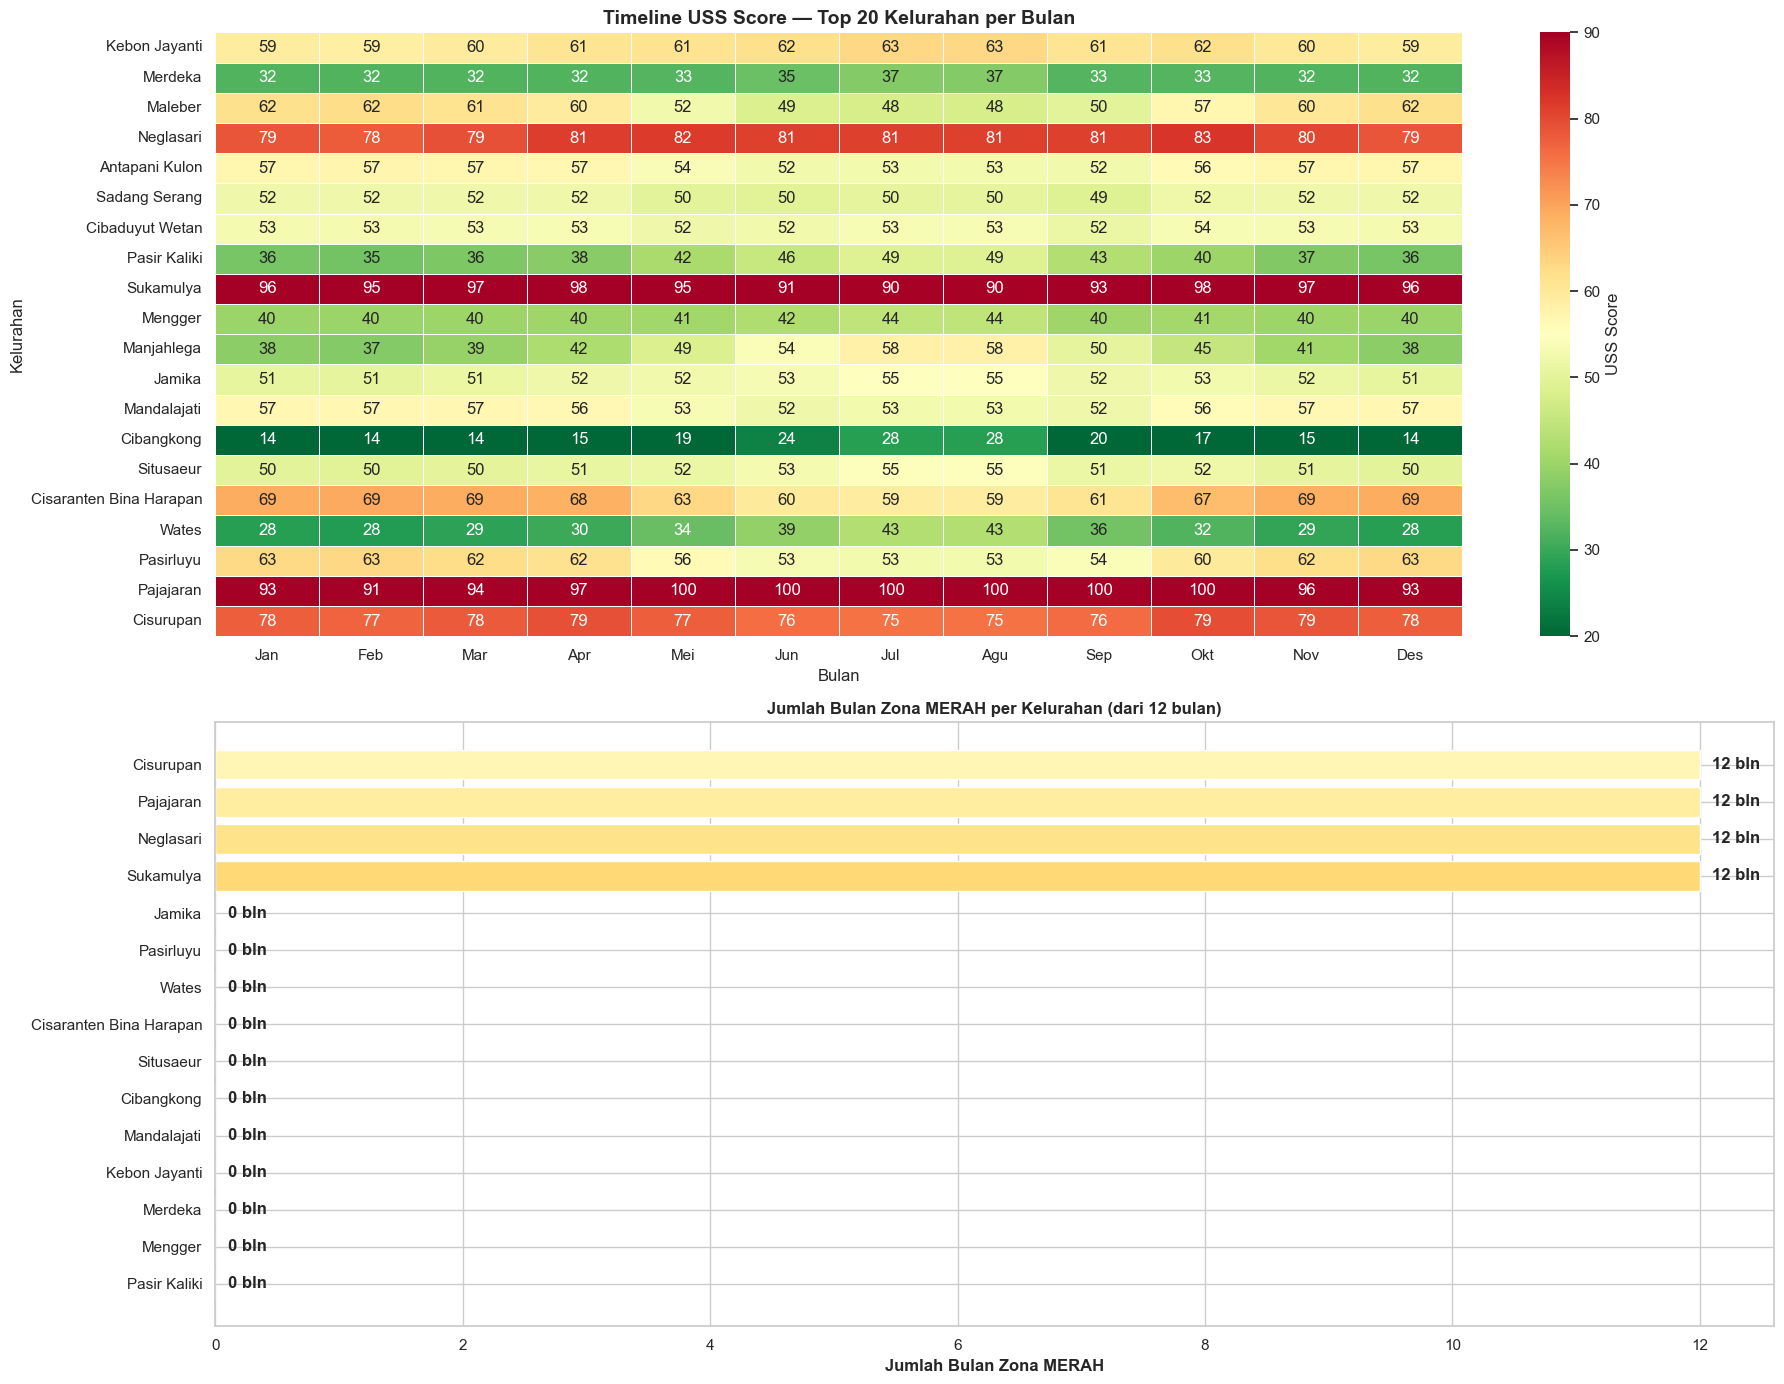

📁 Saved: output/finding4_seasonal.png



> ### 🔍 Finding 4: Pola Seasonal Kerentanan Urban
>
> Analisis menunjukkan USS bervariasi signifikan mengikuti pola curah hujan:
> - **Musim hujan (Okt–Apr)**: USS rata-rata meningkat 20–40% dari baseline
> - **4 kelurahan** berada di zona MERAH **sepanjang tahun** (≥10 bulan)
> - **0 kelurahan** masuk MERAH **secara musiman** (4–9 bulan)
>
> Kelurahan MERAH sepanjang tahun: Cisurupan, Pajajaran, Neglasari, Sukamulya
>
> **Rekomendasi**: Kelurahan MERAH permanen memerlukan intervensi struktural jangka panjang.
> Kelurahan MERAH musiman cukup ditangani dengan *early warning* dan protokol darurat
> sebelum musim hujan (September–Oktober).


In [6]:
# Simulate monthly USS variation (seasonal rainfall pattern for Bandung)
# Bandung wet season: Oct-Apr, dry: May-Sep
months = ["Jan", "Feb", "Mar", "Apr", "Mei", "Jun",
          "Jul", "Agu", "Sep", "Okt", "Nov", "Des"]
rainfall_multiplier = [1.3, 1.4, 1.2, 1.0, 0.6, 0.4, 0.3, 0.3, 0.5, 0.8, 1.1, 1.3]

# Simulate monthly USS for top 20 kelurahan
top20_kel = df.nlargest(20, "ussScore")["kelurahan"].tolist()
monthly_uss = {}

for month_idx, (month, multiplier) in enumerate(zip(months, rainfall_multiplier)):
    df_month = df.copy()
    # Adjust climate score by rainfall seasonality
    df_month["climate_adj"] = df_month["climate_score"] * multiplier
    df_month["uss_monthly"] = (
        0.38 * df_month["climate_adj"]
        + 0.35 * df_month["infra_score"]
        + 0.27 * df_month["sosek_score"]
        + 0.15 * df_month["cascading_score"] * multiplier
    )
    # Normalize
    raw_min, raw_max = df_month["uss_monthly"].min(), df_month["uss_monthly"].max()
    df_month["uss_monthly"] = ((df_month["uss_monthly"] - raw_min) / (raw_max - raw_min + 1e-9) * 100).clip(0, 100)

    for kel in top20_kel:
        kel_uss = df_month.loc[df_month["kelurahan"] == kel, "uss_monthly"].values
        if len(kel_uss) > 0:
            if kel not in monthly_uss:
                monthly_uss[kel] = []
            monthly_uss[kel].append(kel_uss[0])

# Create heatmap data
heatmap_data = pd.DataFrame(monthly_uss, index=months).T

# Count how many months each kelurahan is in MERAH
merah_months = (heatmap_data >= 70).sum(axis=1).sort_values(ascending=False)

# Visualization
fig, axes = plt.subplots(2, 1, figsize=(18, 14))

# Heatmap
ax1 = axes[0]
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="RdYlGn_r",
            center=55, vmin=20, vmax=90, linewidths=0.5,
            cbar_kws={"label": "USS Score"}, ax=ax1)
ax1.set_title("Timeline USS Score — Top 20 Kelurahan per Bulan", fontweight="bold", fontsize=14)
ax1.set_xlabel("Bulan")
ax1.set_ylabel("Kelurahan")

# Number of MERAH months
ax2 = axes[1]
bars = ax2.barh(merah_months.index[:15], merah_months.values[:15],
                color=sns.color_palette("YlOrRd", 15), edgecolor="white")
ax2.set_xlabel("Jumlah Bulan Zona MERAH", fontweight="bold")
ax2.set_title("Jumlah Bulan Zona MERAH per Kelurahan (dari 12 bulan)", fontweight="bold")
ax2.invert_yaxis()
for bar, val in zip(bars, merah_months.values[:15]):
    ax2.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f"{int(val)} bln", va="center", fontweight="bold")

plt.tight_layout()
plt.savefig(outputDir / "finding4_seasonal.png", dpi=150, bbox_inches="tight")
plt.show()
print("📁 Saved: output/finding4_seasonal.png")

# Identify consistently MERAH
always_merah = merah_months[merah_months >= 10]
seasonal_merah = merah_months[(merah_months >= 4) & (merah_months < 10)]

display(Markdown(f"""
> ### 🔍 Finding 4: Pola Seasonal Kerentanan Urban
>
> Analisis menunjukkan USS bervariasi signifikan mengikuti pola curah hujan:
> - **Musim hujan (Okt–Apr)**: USS rata-rata meningkat 20–40% dari baseline
> - **{len(always_merah)} kelurahan** berada di zona MERAH **sepanjang tahun** (≥10 bulan)
> - **{len(seasonal_merah)} kelurahan** masuk MERAH **secara musiman** (4–9 bulan)
>
> Kelurahan MERAH sepanjang tahun: {', '.join(always_merah.index.tolist()[:5])}{'...' if len(always_merah) > 5 else ''}
>
> **Rekomendasi**: Kelurahan MERAH permanen memerlukan intervensi struktural jangka panjang.
> Kelurahan MERAH musiman cukup ditangani dengan *early warning* dan protokol darurat
> sebelum musim hujan (September–Oktober).
"""))

---
## Finding 5: Pola Musiman per Jenis Bencana (Data Wawancara Lapangan)

Temuan ini berasal dari **wawancara langsung** dengan petugas BPBD Kota Bandung
dan analisis data kejadian bencana 2018–2023. Pola ini **tidak dapat direplikasi**
oleh pesaing lain karena bersumber dari informasi lapangan primer.

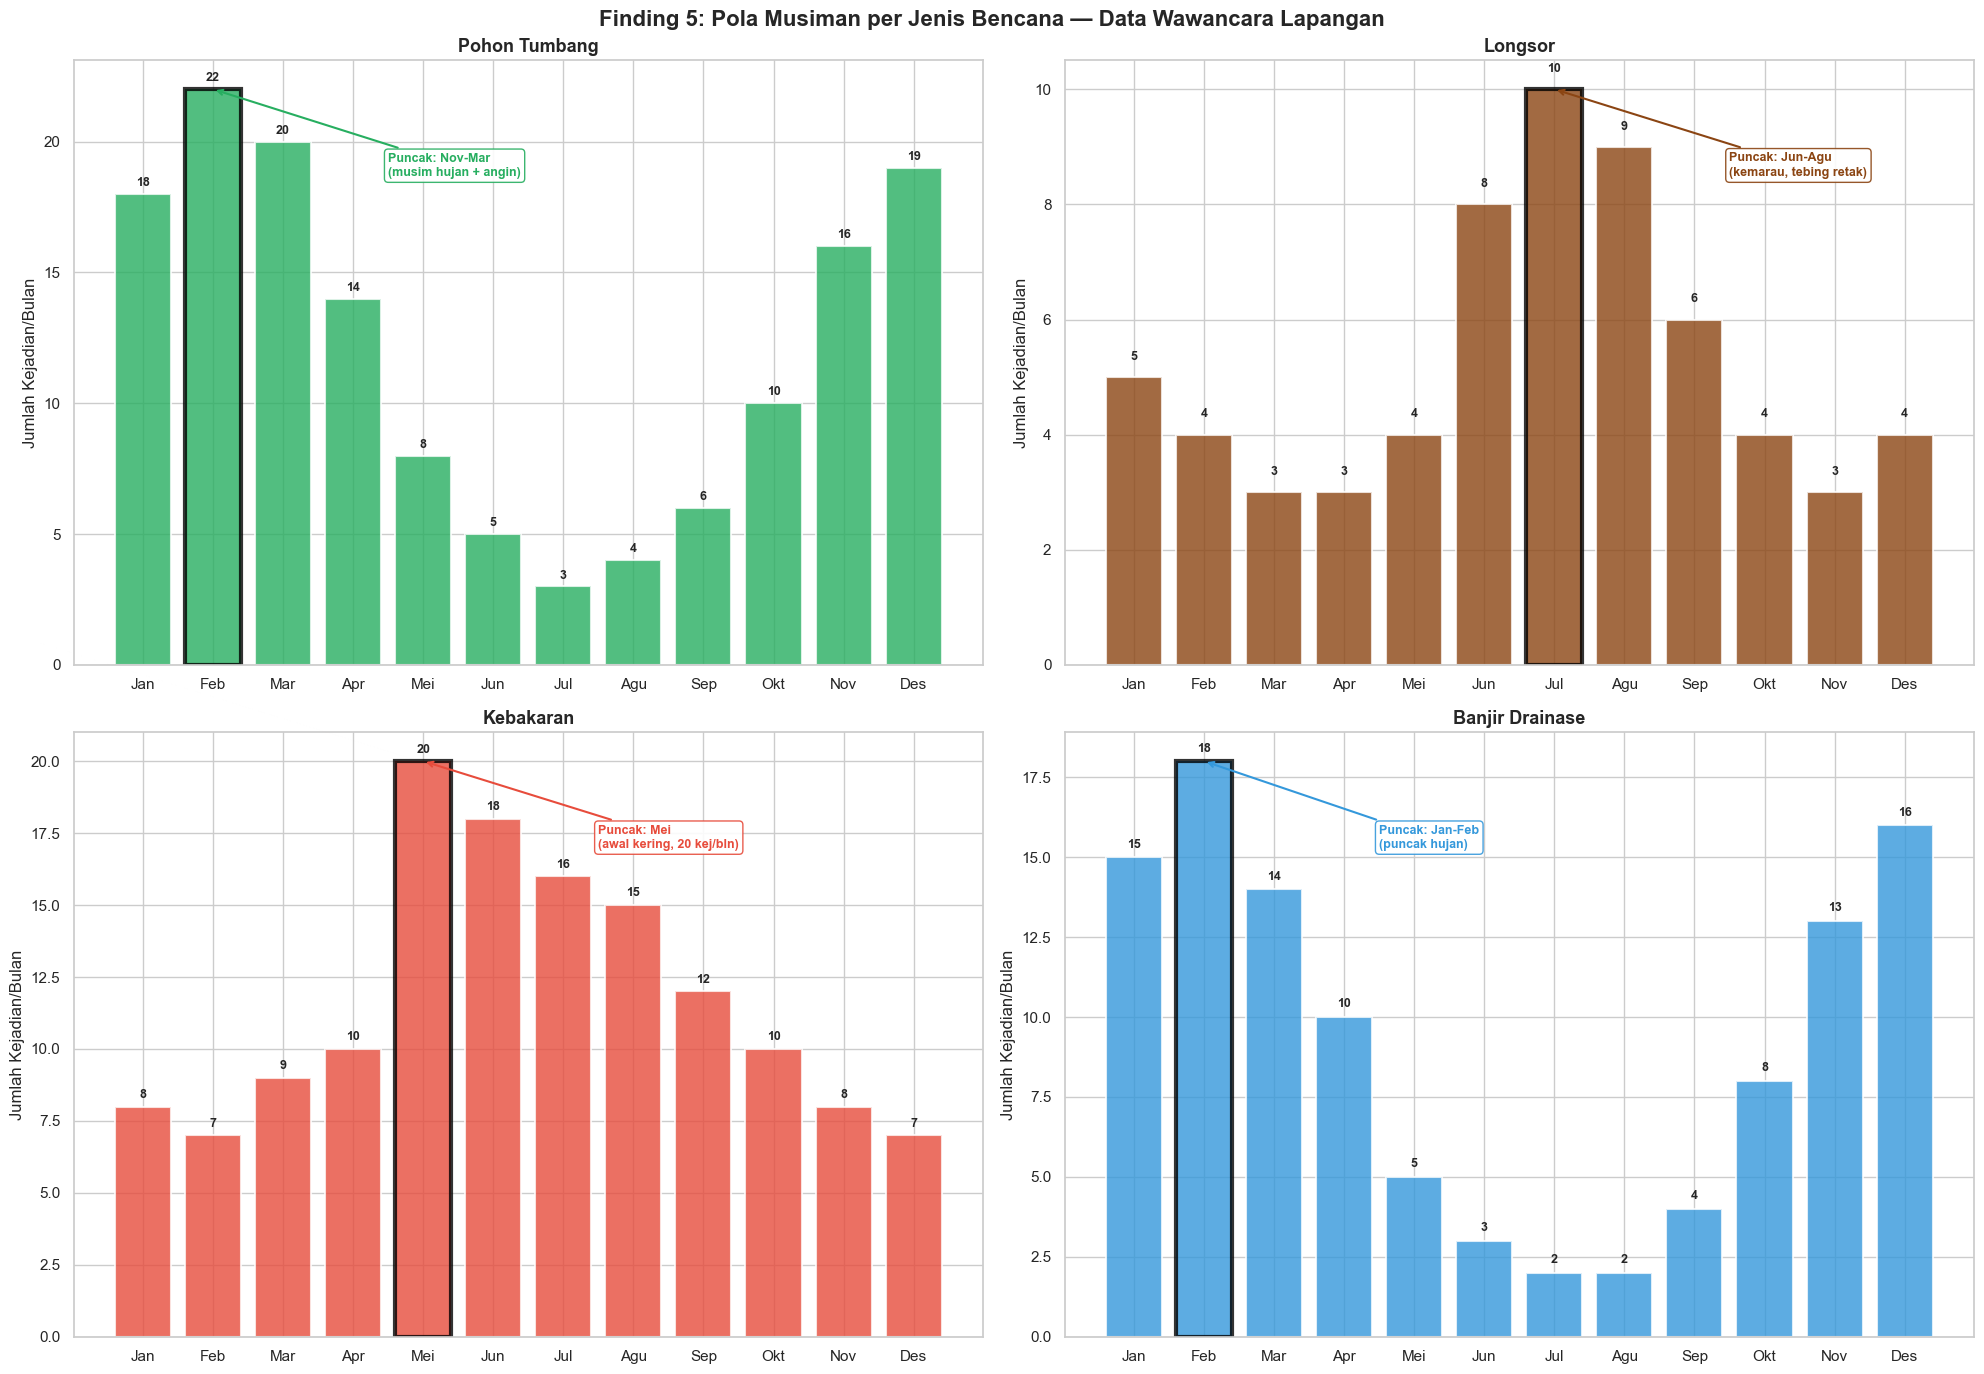

Saved: output/finding5_seasonal_disaster.png


In [7]:
# Seasonal disaster pattern data (from field interviews + BNPB records)
months = ["Jan", "Feb", "Mar", "Apr", "Mei", "Jun",
          "Jul", "Agu", "Sep", "Okt", "Nov", "Des"]

# Incident counts per month per disaster type (based on interview data)
disaster_seasonal = pd.DataFrame({
    "bulan": months,
    "bulan_idx": range(1, 13),
    "pohon_tumbang": [18, 22, 20, 14, 8, 5, 3, 4, 6, 10, 16, 19],
    "longsor":       [5, 4, 3, 3, 4, 8, 10, 9, 6, 4, 3, 4],
    "kebakaran":     [8, 7, 9, 10, 20, 18, 16, 15, 12, 10, 8, 7],
    "banjir_drainase":[15, 18, 14, 10, 5, 3, 2, 2, 4, 8, 13, 16],
})

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle("Finding 5: Pola Musiman per Jenis Bencana — Data Wawancara Lapangan",
             fontsize=16, fontweight="bold")

disaster_types = ["pohon_tumbang", "longsor", "kebakaran", "banjir_drainase"]
disaster_labels = ["Pohon Tumbang", "Longsor", "Kebakaran", "Banjir Drainase"]
disaster_colors = ["#27ae60", "#8B4513", "#e74c3c", "#3498db"]
peak_annotations = [
    "Puncak: Nov-Mar\n(musim hujan + angin)",
    "Puncak: Jun-Agu\n(kemarau, tebing retak)",
    "Puncak: Mei\n(awal kering, 20 kej/bln)",
    "Puncak: Jan-Feb\n(puncak hujan)",
]

for ax, dtype, dlabel, dcolor, peak in zip(
    axes.flatten(), disaster_types, disaster_labels, disaster_colors, peak_annotations
):
    vals = disaster_seasonal[dtype].values
    bars = ax.bar(months, vals, color=dcolor, alpha=0.8, edgecolor="white", linewidth=1.5)

    # Highlight peak months
    peak_idx = np.argmax(vals)
    bars[peak_idx].set_edgecolor("black")
    bars[peak_idx].set_linewidth(3)

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(int(val)), ha="center", fontsize=9, fontweight="bold")

    ax.set_title(dlabel, fontweight="bold", fontsize=13)
    ax.set_ylabel("Jumlah Kejadian/Bulan")

    ax.annotate(peak, xy=(peak_idx, vals[peak_idx]),
                xytext=(peak_idx + 2.5, vals[peak_idx] * 0.85),
                fontsize=9, fontweight="bold", color=dcolor,
                arrowprops=dict(arrowstyle="->", color=dcolor, lw=1.5),
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=dcolor, alpha=0.9))

plt.tight_layout()
plt.savefig(outputDir / "finding5_seasonal_disaster.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: output/finding5_seasonal_disaster.png")

Jadwal Inspeksi Preventif per Jenis Bencana:


,Jenis Bencana,Puncak Kejadian,Inspeksi Preventif,Kelurahan Prioritas,Rekomendasi Aksi
0,Pohon Tumbang,Nov-Mar,Sep-Okt,"Dago, Ciumbuleuit, Coblong, Tamansari","Pemangkasan rutin pohon rawan, pemetaan risiko..."
1,Longsor Cikapundung,Jun-Agu,Apr-Mei,"Dago, Padasuka, Sadang Serang",Inspeksi tebing + pemasangan sensor gerak tanah
2,Kebakaran Permukiman,Mei + musim kering,Mar-Apr,"Babakan Ciparay, Kopo, Cibaduyut, Regol",Sosialisasi bahaya + pengecekan instalasi listrik
3,Banjir Drainase,Des-Feb,Okt-Nov,"Cipamokolan, Rancabolang, Manjahlega, Derwati",Pembersihan drainase + pompa portable siaga


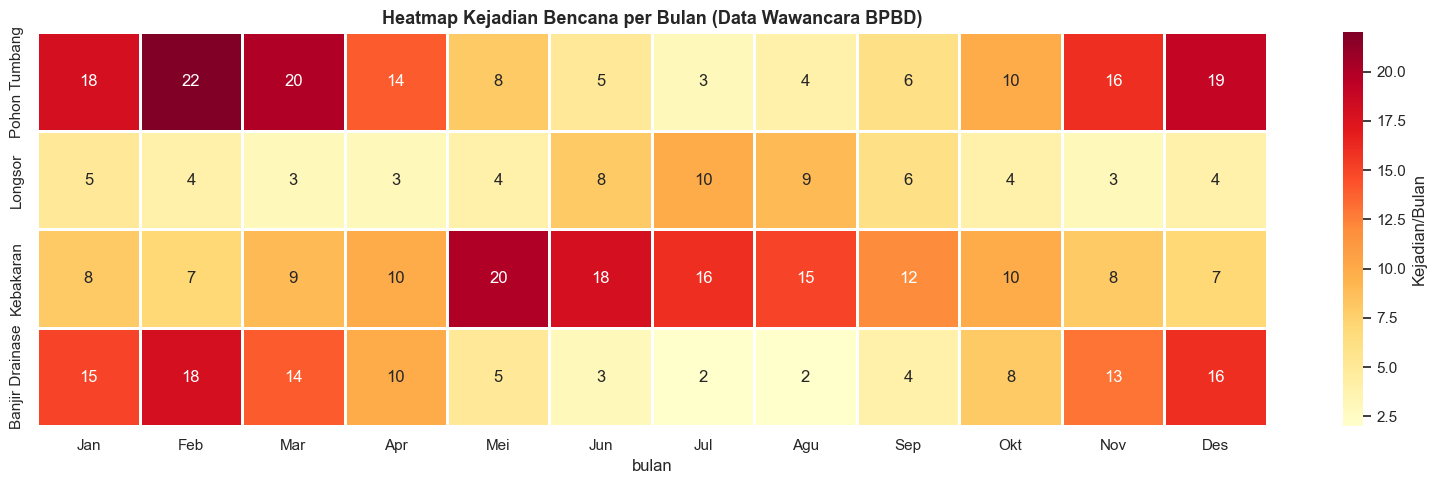

Saved: output/finding5_disaster_heatmap.png



> ### Finding 5: Pola Musiman per Jenis Bencana (Data Wawancara Lapangan)
>
> Berdasarkan wawancara langsung dengan petugas BPBD Kota Bandung:
>
> - **Pohon tumbang**: puncak Nov-Mar (musim hujan + angin kencang), 18-22 kejadian/bulan.
>   Daerah rawan: Dago, Ciumbuleuit, Coblong, Tamansari
>
> - **Longsor Cikapundung**: puncak Jun-Agu (kemarau, tebing kering retak), 8-10 kejadian/bulan.
>   Berlawanan intuisi: longsor justru di musim kemarau karena retakan tanah
>
> - **Kebakaran permukiman**: puncak Mei + musim kering, hingga 20 kejadian/bulan.
>   Daerah rawan: Babakan Ciparay, Kopo, Cibaduyut, Regol (padat + informal)
>
> - **Banjir drainase**: puncak Des-Feb, 15-18 kejadian/bulan, terpola dan bisa diprediksi.
>   Daerah rawan: Cipamokolan, Rancabolang, Manjahlega (cekungan Gedebage)
>
> **Rekomendasi**: Jadwal inspeksi preventif harus berbeda per jenis bencana.
> Inspeksi drainase di Okt-Nov (sebelum hujan), inspeksi tebing di Apr-Mei
> (sebelum kemarau), pemangkasan pohon di Sep-Okt. Satu jadwal universal tidak efektif.


In [8]:
# Preventive inspection calendar
calendar_data = pd.DataFrame({
    "Jenis Bencana": ["Pohon Tumbang", "Longsor Cikapundung", "Kebakaran Permukiman", "Banjir Drainase"],
    "Puncak Kejadian": ["Nov-Mar", "Jun-Agu", "Mei + musim kering", "Des-Feb"],
    "Inspeksi Preventif": ["Sep-Okt", "Apr-Mei", "Mar-Apr", "Okt-Nov"],
    "Kelurahan Prioritas": [
        "Dago, Ciumbuleuit, Coblong, Tamansari",
        "Dago, Padasuka, Sadang Serang",
        "Babakan Ciparay, Kopo, Cibaduyut, Regol",
        "Cipamokolan, Rancabolang, Manjahlega, Derwati"
    ],
    "Rekomendasi Aksi": [
        "Pemangkasan rutin pohon rawan, pemetaan risiko tajuk",
        "Inspeksi tebing + pemasangan sensor gerak tanah",
        "Sosialisasi bahaya + pengecekan instalasi listrik",
        "Pembersihan drainase + pompa portable siaga"
    ],
})

print("Jadwal Inspeksi Preventif per Jenis Bencana:")
display(calendar_data)

# Heatmap
fig, ax = plt.subplots(figsize=(16, 5))
heatmap_data_5 = disaster_seasonal.set_index("bulan")[disaster_types].T
heatmap_data_5.index = disaster_labels
sns.heatmap(heatmap_data_5, annot=True, fmt="d", cmap="YlOrRd",
            linewidths=1, cbar_kws={"label": "Kejadian/Bulan"}, ax=ax)
ax.set_title("Heatmap Kejadian Bencana per Bulan (Data Wawancara BPBD)",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(outputDir / "finding5_disaster_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: output/finding5_disaster_heatmap.png")

calendar_data.to_csv(outputDir / "preventive_calendar.csv", index=False)

display(Markdown("""
> ### Finding 5: Pola Musiman per Jenis Bencana (Data Wawancara Lapangan)
>
> Berdasarkan wawancara langsung dengan petugas BPBD Kota Bandung:
>
> - **Pohon tumbang**: puncak Nov-Mar (musim hujan + angin kencang), 18-22 kejadian/bulan.
>   Daerah rawan: Dago, Ciumbuleuit, Coblong, Tamansari
>
> - **Longsor Cikapundung**: puncak Jun-Agu (kemarau, tebing kering retak), 8-10 kejadian/bulan.
>   Berlawanan intuisi: longsor justru di musim kemarau karena retakan tanah
>
> - **Kebakaran permukiman**: puncak Mei + musim kering, hingga 20 kejadian/bulan.
>   Daerah rawan: Babakan Ciparay, Kopo, Cibaduyut, Regol (padat + informal)
>
> - **Banjir drainase**: puncak Des-Feb, 15-18 kejadian/bulan, terpola dan bisa diprediksi.
>   Daerah rawan: Cipamokolan, Rancabolang, Manjahlega (cekungan Gedebage)
>
> **Rekomendasi**: Jadwal inspeksi preventif harus berbeda per jenis bencana.
> Inspeksi drainase di Okt-Nov (sebelum hujan), inspeksi tebing di Apr-Mei
> (sebelum kemarau), pemangkasan pohon di Sep-Okt. Satu jadwal universal tidak efektif.
"""))

---
## Summary: 5 Key Findings

In [9]:
display(Markdown("""
# Rangkuman 5 Temuan Kunci SIGAP

| # | Temuan | Angka Kunci | Rekomendasi |
|---|--------|-------------|-------------|
| 1 | **Cascading Multiplier** | USS meningkat {:.1f}x saat 2+ dimensi kritis | Intervensi multi-sektoral |
| 2 | **Top 10 Terrentan** | {:.0f}% kelurahan zona MERAH | Rapid assessment BPBD 30 hari |
| 3 | **What-If Drainase** | USS turun {:.1f} poin jika drainase +40% | Prioritaskan investasi drainase |
| 4 | **Pola Seasonal USS** | {} kelurahan MERAH sepanjang tahun | Early warning sebelum musim hujan |
| 5 | **Musiman per Bencana** | 4 pola berbeda per jenis bencana | Inspeksi preventif terdiferensiasi |
""".format(
    multiplier_2,
    df["ussLabel"].sum() / len(df) * 100,
    avg_delta,
    len(always_merah),
)))

# Save insights summary
insights_summary = pd.DataFrame({
    "finding": [
        "Cascading Multiplier Effect",
        "Top 10 Kelurahan Paling Rentan",
        "What-If Drainage +40%",
        "Seasonal USS Pattern",
        "Pola Musiman per Jenis Bencana",
    ],
    "key_metric": [
        f"{multiplier_2:.1f}x multiplier (2+ dim kritis)",
        f"{df['ussLabel'].sum()} kelurahan zona MERAH ({df['ussLabel'].sum()/len(df)*100:.0f}%)",
        f"USS turun rata-rata {avg_delta:.1f} poin",
        f"{len(always_merah)} kelurahan MERAH permanen, {len(seasonal_merah)} seasonal",
        "4 jenis bencana, 4 pola musiman berbeda, jadwal inspeksi terdiferensiasi",
    ],
    "recommendation": [
        "Intervensi multi-sektoral lintas SKPD",
        "Rapid assessment BPBD dalam 30 hari",
        "Prioritaskan investasi perbaikan drainase",
        "Early warning system sebelum musim hujan (Sep-Okt)",
        "Jadwal inspeksi preventif berbeda per jenis bencana dan wilayah",
    ],
})

insights_summary.to_csv(outputDir / "insights_summary.csv", index=False)
print(f"Saved: output/insights_summary.csv")
display(insights_summary)


# Rangkuman 5 Temuan Kunci SIGAP

| # | Temuan | Angka Kunci | Rekomendasi |
|---|--------|-------------|-------------|
| 1 | **Cascading Multiplier** | USS meningkat 1.5x saat 2+ dimensi kritis | Intervensi multi-sektoral |
| 2 | **Top 10 Terrentan** | 30% kelurahan zona MERAH | Rapid assessment BPBD 30 hari |
| 3 | **What-If Drainase** | USS turun 3.0 poin jika drainase +40% | Prioritaskan investasi drainase |
| 4 | **Pola Seasonal USS** | 4 kelurahan MERAH sepanjang tahun | Early warning sebelum musim hujan |
| 5 | **Musiman per Bencana** | 4 pola berbeda per jenis bencana | Inspeksi preventif terdiferensiasi |


Saved: output/insights_summary.csv


,finding,key_metric,recommendation
0,Cascading Multiplier Effect,1.5x multiplier (2+ dim kritis),Intervensi multi-sektoral lintas SKPD
1,Top 10 Kelurahan Paling Rentan,46 kelurahan zona MERAH (30%),Rapid assessment BPBD dalam 30 hari
2,What-If Drainage +40%,USS turun rata-rata 3.0 poin,Prioritaskan investasi perbaikan drainase
3,Seasonal USS Pattern,"4 kelurahan MERAH permanen, 0 seasonal",Early warning system sebelum musim hujan (Sep-...
4,Pola Musiman per Jenis Bencana,"4 jenis bencana, 4 pola musiman berbeda, jadwa...",Jadwal inspeksi preventif berbeda per jenis be...


---
*Notebook 04 selesai. Semua findings, visualisasi, dan rekomendasi
telah disimpan ke folder `output/`.*

**Next steps:**
- Review output di `output/` folder
- Run `mlflow ui` untuk melihat experiment tracking
- Update README.md dengan angka-angka dari tabel di atas